# LP modes of a step-index fiber: the characteristic equation with modified Bessel $K$

The previous notebook used the Bessel zeros to get a fiber's single-mode limit. The full story needs two
Bessel families, because a guided mode is **oscillatory in the core** and **evanescent in the cladding**:

- Core ($r<a$, higher index $n_1$): the field is $J_\ell(u\,r/a)$, with $u=a\sqrt{n_1^2k_0^2-\beta^2}$
  (real, oscillatory) -- an ordinary Bessel function.
- Cladding ($r>a$, index $n_2$): the field must **decay**, so it is the **modified Bessel function**
  $K_\ell(w\,r/a)$, with $w=a\sqrt{\beta^2-n_2^2k_0^2}$ -- $K_\ell$ falls off like $e^{-w r/a}$.

Matching the field and its slope at $r=a$ (weak-guidance / LP approximation) gives the **characteristic
equation**
$$u\,\frac{J_{\ell+1}(u)}{J_\ell(u)}=w\,\frac{K_{\ell+1}(w)}{K_\ell(w)},\qquad u^2+w^2=V^2,$$
with the normalized frequency $V=a k_0\,\mathrm{NA}$. Its roots are the guided modes $\mathrm{LP}_{\ell m}$;
their cutoffs are (again) Bessel zeros, and $\mathrm{LP}_{11}$ cutting on at $V=2.405$ recovers the
single-mode limit. We verify $K_\ell$ solves the modified Bessel equation (SymPy), solve the characteristic
equation for the modes (SciPy), check the cutoffs, and plot the core-plus-cladding field profiles.
Self-contained: NumPy, SymPy, SciPy, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


In [2]:
from scipy.special import jv, kv, jn_zeros
from scipy.optimize import brentq

## The modified Bessel function $K_\ell$: the evanescent cladding field

$K_\ell$ solves the **modified** Bessel equation $x^2y''+xy'-(x^2+\ell^2)y=0$ (note the $+x^2$: solutions
grow/decay rather than oscillate) and $K_\ell(x)\to\sqrt{\pi/2x}\,e^{-x}$ -- exponential decay, exactly what
a bound cladding field needs. SymPy confirms it solves the equation; the plot contrasts the oscillating
$J_\ell$ with the decaying $K_\ell$.

In [3]:
x = sp.symbols('x', positive=True)
for order in (0, 1, 2):
    y = sp.besselk(order, x)
    residual = sp.simplify(x**2*sp.diff(y, x, 2) + x*sp.diff(y, x) - (x**2 + order**2)*y)
    assert residual == 0
    print(f"K_{order} solves the modified Bessel equation (residual {residual})")
print("K_0(1,3,5) =", np.round(kv(0, [1., 3., 5.]), 5), " -> exponential decay (evanescent)")

K_0 solves the modified Bessel equation (residual 0)
K_1 solves the modified Bessel equation (residual 0)
K_2 solves the modified Bessel equation (residual 0)
K_0(1,3,5) = [0.42102 0.03474 0.00369]  -> exponential decay (evanescent)


## Solving the characteristic equation for the LP modes

Write the equation as $F(u)=u\,J_{\ell+1}(u)\,K_\ell(w)-w\,K_{\ell+1}(w)\,J_\ell(u)=0$ (smooth, no poles),
scan $u\in(0,V)$ for sign changes, and bracket each root. Every root is a guided mode $\mathrm{LP}_{\ell m}$
with normalized propagation constant $b=1-(u/V)^2\in(0,1)$ (near 1 = tightly bound). Here $V=5$.

In [4]:
def lp_modes(V, l_max=5):
    modes = []
    for l in range(l_max + 1):
        def F(u):
            w = np.sqrt(max(V**2 - u**2, 1e-12))
            return u*jv(l + 1, u)*kv(l, w) - w*kv(l + 1, w)*jv(l, u)
        us = np.linspace(1e-4, V - 1e-4, 6000)
        vals = np.array([F(u) for u in us])
        m = 0
        for i in range(len(us) - 1):
            if np.isfinite(vals[i]) and np.isfinite(vals[i + 1]) and vals[i]*vals[i + 1] < 0:
                u0 = brentq(F, us[i], us[i + 1], maxiter=200)
                m += 1
                modes.append({"l": l, "m": m, "u": round(u0, 4),
                              "w": round(float(np.sqrt(V**2 - u0**2)), 4), "b": round(1 - (u0/V)**2, 4)})
    return modes

V = 5.0
modes = lp_modes(V)
n1, n2 = 1.4457, 1.4378                                             # typical silica core/cladding
for row in modes:
    row["n_eff"] = round(float(np.sqrt(n2**2 + row["b"]*(n1**2 - n2**2))), 6)
print(f"V = {V}:  {len(modes)} guided LP modes")
print(pd.DataFrame(modes).to_string(index=False))
assert any(r["l"] == 0 and r["m"] == 1 for r in modes)             # LP01 always present
assert all(0 < r["b"] < 1 for r in modes)                          # bound modes

V = 5.0:  4 guided LP modes
 l  m      u      w      b    n_eff
 0  1 1.9941 4.5852 0.8409 1.444446
 0  2 4.4288 2.3207 0.2154 1.439505
 1  1 3.1527 3.8808 0.6024 1.442564
 2  1 4.1788 2.7454 0.3015 1.440186


## Cutoffs are Bessel zeros; $\mathrm{LP}_{11}$ at $V=2.405$ is the single-mode limit

A mode cuts off when $w\to0$ (field no longer bound). For $\mathrm{LP}_{\ell m}$ with $\ell\ge1$ the cutoff
is the $m$-th zero of $J_{\ell-1}$; $\mathrm{LP}_{01}$ has no cutoff. So $\mathrm{LP}_{11}$ (first zero of
$J_0=2.405$) is the second mode to appear -- below it the fiber is single-mode. We confirm the mode count
jumps from 1 to 2 as $V$ crosses $2.405$.

In [5]:
print("LP11 cutoff = first zero of J_0 =", round(jn_zeros(0, 1)[0], 4), " (single-mode below this)")
print("LP21/LP02 cutoff = first zero of J_1 =", round(jn_zeros(1, 1)[0], 4))
n_below = len(lp_modes(2.30, l_max=3))
n_above = len(lp_modes(2.50, l_max=3))
print(f"modes at V=2.30: {n_below}  (single-mode)   modes at V=2.50: {n_above}  (LP11 turns on)")
assert n_below == 1 and n_above == 2

LP11 cutoff = first zero of J_0 = 2.4048  (single-mode below this)
LP21/LP02 cutoff = first zero of J_1 = 3.8317


modes at V=2.30: 1  (single-mode)   modes at V=2.50: 2  (LP11 turns on)


## Mode field profiles: $J_\ell$ in the core, $K_\ell$ in the cladding

Each mode's radial field is $J_\ell(u r/a)$ inside and $[J_\ell(u)/K_\ell(w)]K_\ell(w r/a)$ outside --
continuous at $r=a$, oscillatory then exponentially decaying. This is the shape the light actually takes in
the fiber.

In [6]:
def profile(l, u, w, r_over_a):
    core = jv(l, u*r_over_a)
    clad = jv(l, u)/kv(l, w)*kv(l, w*r_over_a)
    return np.where(r_over_a <= 1, core, clad)

ra = np.linspace(1e-3, 3, 400)
checked = []
for row in modes:
    l, u, w = row["l"], row["u"], row["w"]
    p = profile(l, u, w, ra)
    # continuity at r = a
    assert abs(profile(l, u, w, np.array([0.999]))[0] - profile(l, u, w, np.array([1.001]))[0]) < 0.02
    checked.append((l, row["m"]))
print("field profiles continuous at the core-cladding boundary for:", checked)

field profiles continuous at the core-cladding boundary for: [(0, 1), (0, 2), (1, 1), (2, 1)]


## Plots

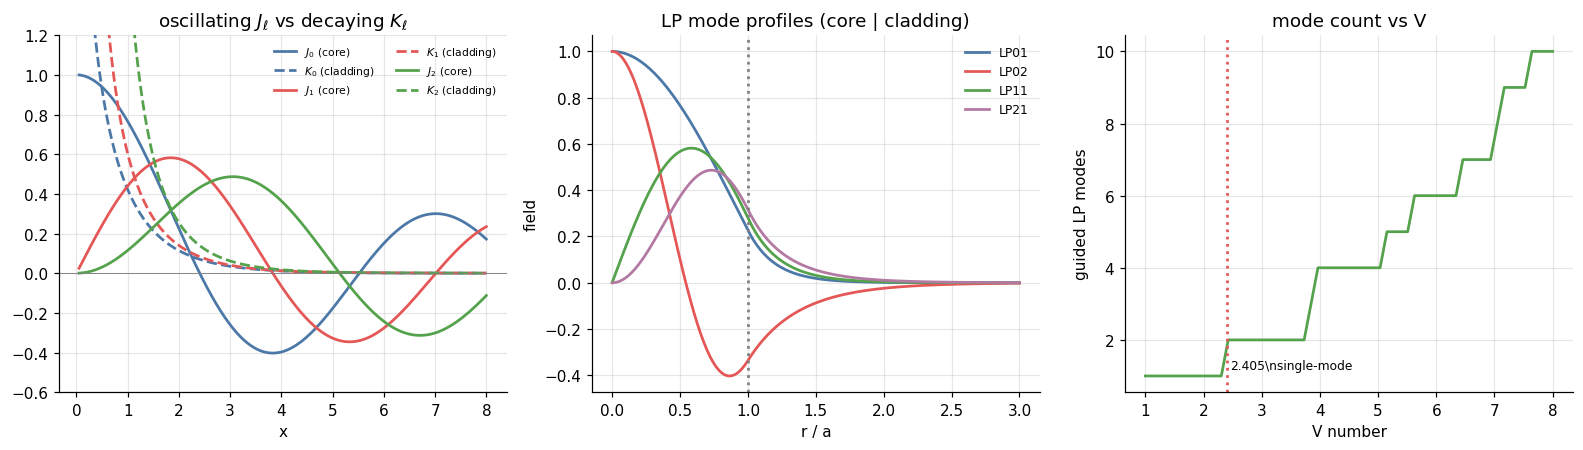

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
xs = np.linspace(0.05, 8, 400)
for l, col in zip((0, 1, 2), ("#4C78A8", "#E45756", "#54A24B")):
    ax[0].plot(xs, jv(l, xs), color=col, label=f"$J_{l}$ (core)")
    ax[0].plot(xs, kv(l, xs), "--", color=col, label=f"$K_{l}$ (cladding)")
ax[0].set_ylim(-0.6, 1.2); ax[0].axhline(0, color="gray", lw=0.6)
ax[0].set_xlabel("x"); ax[0].set_title("oscillating $J_\\ell$ vs decaying $K_\\ell$"); ax[0].legend(fontsize=7, ncol=2)
# field profiles of the first few modes
for row, col in zip(modes[:4], ("#4C78A8", "#E45756", "#54A24B", "#B279A2")):
    ax[1].plot(ra, profile(row["l"], row["u"], row["w"], ra), color=col, label=f"LP{row['l']}{row['m']}")
ax[1].axvline(1.0, ls=":", color="gray"); ax[1].set_xlabel("r / a"); ax[1].set_ylabel("field")
ax[1].set_title("LP mode profiles (core | cladding)"); ax[1].legend(fontsize=8)
# b-V style: number of guided modes vs V
Vs = np.linspace(1.0, 8.0, 60)
ax[2].plot(Vs, [len(lp_modes(V, l_max=6)) for V in Vs], color="#54A24B")
ax[2].axvline(2.405, ls=":", color="#E45756"); ax[2].text(2.45, 1.2, "2.405\\nsingle-mode", fontsize=8)
ax[2].set_xlabel("V number"); ax[2].set_ylabel("guided LP modes"); ax[2].set_title("mode count vs V")
plt.tight_layout(); plt.show()

## Summary

- A guided fiber mode is **oscillatory in the core** ($J_\ell$) and **evanescent in the cladding**
  ($K_\ell$, the modified Bessel function that decays like $e^{-w r/a}$, SymPy-verified).
- Matching field and slope at the boundary gives the **characteristic equation**
  $u\,J_{\ell+1}(u)/J_\ell(u)=w\,K_{\ell+1}(w)/K_\ell(w)$ with $u^2+w^2=V^2$; its roots are the
  $\mathrm{LP}_{\ell m}$ modes (solved with SciPy, $b\in(0,1)$, $n_\mathrm{eff}$ tabulated).
- **Cutoffs are Bessel zeros**: $\mathrm{LP}_{11}$ at $V=2.405$ (first zero of $J_0$) sets the single-mode
  limit -- the mode count jumps 1 -> 2 there (verified).

Subject-verb-object: the core oscillates; the cladding decays; the boundary matches them; the Bessel zeros
count the modes.